# PlantaIa — análisis ampliado (posterior a la devolución de la Tarea 1)

La devolución de la primera entrega pidió dos cosas: más datos etiquetados de forma manual y no arrastrados, y un análisis que relacione los patrones con lo que le pasa a la planta en vez de limitarse a describirlos. Este notebook retoma los datos de la placa real (`maceta-01`), incorpora la tanda del 1 al 3 de octubre y revisa qué tan sólida es la evidencia. El `01_eda.ipynb` entregado no se modificó.

Todo lo que sigue sale de mediciones reales de la ESP32; no se usan datos generados.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_predict

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
DATOS, SALIDAS = RAIZ / "data", RAIZ / "outputs"
SALIDAS.mkdir(exist_ok=True)

CLASES = ["saludable", "estresada", "marchita"]
COLORES = {"saludable": "#4c9f70", "estresada": "#e6a23c", "marchita": "#c84b4b"}
VARIABLES = {
    "luz_mv": "Luz (mV)",
    "temperatura_c": "Temperatura del aire (°C)",
    "humedad_ambiente_pct": "Humedad del aire (%)",
    "suelo_mv": "Sustrato (mV; mayor = más seco)",
}
V = list(VARIABLES)

## 1. Carga y construcción del dataset

Cada fila se cruza con `data/episodios.csv`: la etiqueta de análisis es la del **episodio** que contiene la fila, no la que mandó la placa fila a fila. Una fila (la primera de la base) trae la hora de la placa en 2025 porque el reloj no estaba sincronizado; se la ubica con la hora del servidor.

In [2]:
raw = pd.read_csv(DATOS / "mediciones_raw_2026-10-08.csv", parse_dates=["ts_servidor"])
# ts_dispositivo trae a veces horas sin zona horaria o de un reloj sin sincronizar (2025):
# esa fila se ubica con la hora del servidor.
ts = pd.to_datetime(raw.ts_dispositivo, utc=True)
raw["ts"] = ts.where(ts >= "2026-01-01", pd.to_datetime(raw.ts_servidor, utc=True))
episodios = pd.read_csv(DATOS / "episodios.csv", parse_dates=["ts_inicio", "ts_fin"])

real = raw[(raw.dispositivo == "maceta-01") & (raw.ts >= "2026-09-12")].copy()

ep = np.full(len(real), np.nan)
clase = np.full(len(real), None, dtype=object)
origen = np.full(len(real), None, dtype=object)
for _, e in episodios.iterrows():
    m = ((real.ts >= e.ts_inicio) & (real.ts < e.ts_fin)).values
    ep[m], clase[m], origen[m] = e.episodio_id, e.clase, e.origen
real = real.assign(episodio=ep, etiqueta=clase, origen_ep=origen)

sin_episodio = real.episodio.isna().sum()
datos = real.dropna(subset=["episodio", *V]).copy()
datos["etiqueta"] = pd.Categorical(datos.etiqueta, categories=CLASES, ordered=True)
datos["hora_local"] = (datos.ts + pd.Timedelta(hours=-3)).dt.hour
datos["es_noche"] = ~datos.hora_local.between(7, 19)
print(f"filas descartadas (fuera de todo episodio o con una variable en null): {sin_episodio:,}")

dt = datos.ts.sort_values().diff().dt.total_seconds()
control = pd.Series({
    "filas": len(datos),
    "días con datos": datos.ts.dt.date.nunique(),
    "horas efectivas de registro": dt.where(dt <= 900, 0).sum() / 3600,
    "episodios": datos.episodio.nunique(),
    "  anclados en una pulsación (manual)": datos[datos.origen_ep == "manual"].episodio.nunique(),
    "  heredados de Preferences (propagada)": datos[datos.origen_ep == "propagada"].episodio.nunique(),
    "  reconstruidos a posteriori (corregida)": datos[datos.origen_ep == "corregida"].episodio.nunique(),
})
display(control.to_frame("valor"))
display(pd.crosstab(datos.etiqueta, datos.origen_ep))

filas descartadas (fuera de todo episodio o con una variable en null): 26


,valor
filas,"6,497.00"
días con datos,8.00
horas efectivas de registro,54.92
episodios,10.00
anclados en una pulsación (manual),7.00
heredados de Preferences (propagada),2.00
reconstruidos a posteriori (corregida),1.00


origen_ep,corregida,manual,propagada
etiqueta,,,
saludable,0,1769,0
estresada,0,1742,21
marchita,1543,1325,97


**Cadencia.** El protocolo pide una muestra cada 5 minutos, pero en la tabla de abajo se ve que **todas las fechas llegan cada 30 s** (99,2 % de los intervalos), incluida la tanda de octubre, y ninguno es de 5 min. El código del firmware dice 5 min desde el 29/9, pero la placa sigue con la versión anterior: no se volvió a flashear (la versión `1.1.0` no cambió, así que desde la base no se distingue). Consecuencias: hay 10 veces más filas por hora de las que prevé el protocolo, y las filas contiguas aportan casi nada de información independiente. El N efectivo son los 10 episodios.

In [3]:
datos = datos.sort_values("ts")
datos["dt_s"] = datos.ts.diff().dt.total_seconds()
cad = (datos[datos.dt_s <= 900].groupby([datos.ts.dt.date, "firmware_version"])
       .dt_s.agg(["count", "median"]).rename(columns={"count": "intervalos", "median": "mediana (s)"}))
display(cad)
print(f"Intervalos de 30 s: {(datos.dt_s.between(25, 35)).mean():.1%} · "
      f"de 5 min (270–330 s): {(datos.dt_s.between(270, 330)).mean():.1%}")

,,intervalos,mediana (s)
ts,firmware_version,,
2026-09-12,1.1.0,114,30.00
2026-09-13,1.1.0,1428,30.00
2026-09-15,1.1.0,358,30.00
2026-09-16,1.1.0,969,30.00
2026-09-17,1.1.0,135,30.00
2026-10-01,1.1.0,1726,30.00
2026-10-02,1.1.0,801,30.00
2026-10-03,1.1.0,958,30.00


Intervalos de 30 s: 99.2% · de 5 min (270–330 s): 0.0%


## 2. La tanda real del 1 al 3 de octubre

**Calidad de la tanda (3.489 filas).**

* Hay tres huecos de 8 a 21 horas, cada uno con un `boot_id` nuevo: son reinicios de la placa. La primera fila de la tabla es el salto de 13 días desde la tanda anterior. El episodio `estresada` del 1/10 y el `saludable` del 2/10 cruzan un hueco.
* 1.056 filas (30 %) llevan `luz_saturada`: el LDR está en el techo del ADC durante las horas de sol. La luz no distingue entre un día claro y uno muy claro.
* Las tres primeras filas tienen `suelo_saturado` (3.124 mV): la sonda todavía no estaba clavada en el sustrato. La pulsación `marchita` de la muestra 3034 se hizo justo en ese momento.

In [4]:
real_nuevo = datos[datos.ts >= "2026-10-01"]
huecos = real_nuevo[real_nuevo.dt_s > 900][["ts", "dt_s", "boot_id"]].assign(horas=lambda d: d.dt_s / 3600)
print("Huecos > 15 min en la tanda del 1–3/10 (cada uno es un corte de luz o de WiFi):")
display(huecos[["ts", "horas", "boot_id"]].round(2))
print("Avisos de los sensores en esa tanda:")
display(raw[(raw.dispositivo == "maceta-01") & (raw.ts >= "2026-10-01")].errores.fillna("ninguno")
        .value_counts().to_frame("filas"))
print("Primeras filas de la tanda (sonda de suelo recién colocada):")
display(raw[(raw.dispositivo == "maceta-01") & (raw.ts >= "2026-10-01")]
        [["ts", "suelo_mv", "condicion_etiqueta", "etiqueta_origen", "errores"]].head(6))

Huecos > 15 min en la tanda del 1–3/10 (cada uno es un corte de luz o de WiFi):


,ts,horas,boot_id
3034,2026-10-01 00:39:57+00:00,317.68,45
4761,2026-10-02 00:50:41+00:00,9.64,46
5028,2026-10-02 11:13:08+00:00,8.15,47
5564,2026-10-03 12:36:19+00:00,20.92,48


Avisos de los sensores en esa tanda:


,filas
errores,
ninguno,2430
luz_saturada,1056
suelo_saturado,3


Primeras filas de la tanda (sonda de suelo recién colocada):


,ts,suelo_mv,condicion_etiqueta,etiqueta_origen,errores
3034,2026-10-01 00:39:57+00:00,"3,124.00",marchita,manual,suelo_saturado
3035,2026-10-01 00:40:27+00:00,"3,124.00",marchita,propagada,suelo_saturado
3036,2026-10-01 00:40:57+00:00,"3,124.00",marchita,propagada,suelo_saturado
3037,2026-10-01 00:41:27+00:00,"1,936.00",marchita,propagada,NaN
3038,2026-10-01 00:41:57+00:00,"1,845.00",marchita,propagada,NaN
3039,2026-10-01 00:42:27+00:00,"2,012.00",marchita,propagada,NaN


**Qué cambió respecto de la primera entrega.** El dataset pasa de 7 a 10 episodios, ahora con 7 anclados por una pulsación del botón (`manual`), y se suman tres días de calendario distintos. Sigue siendo poco: 10 episodios es el N efectivo, no las 6.497 filas.

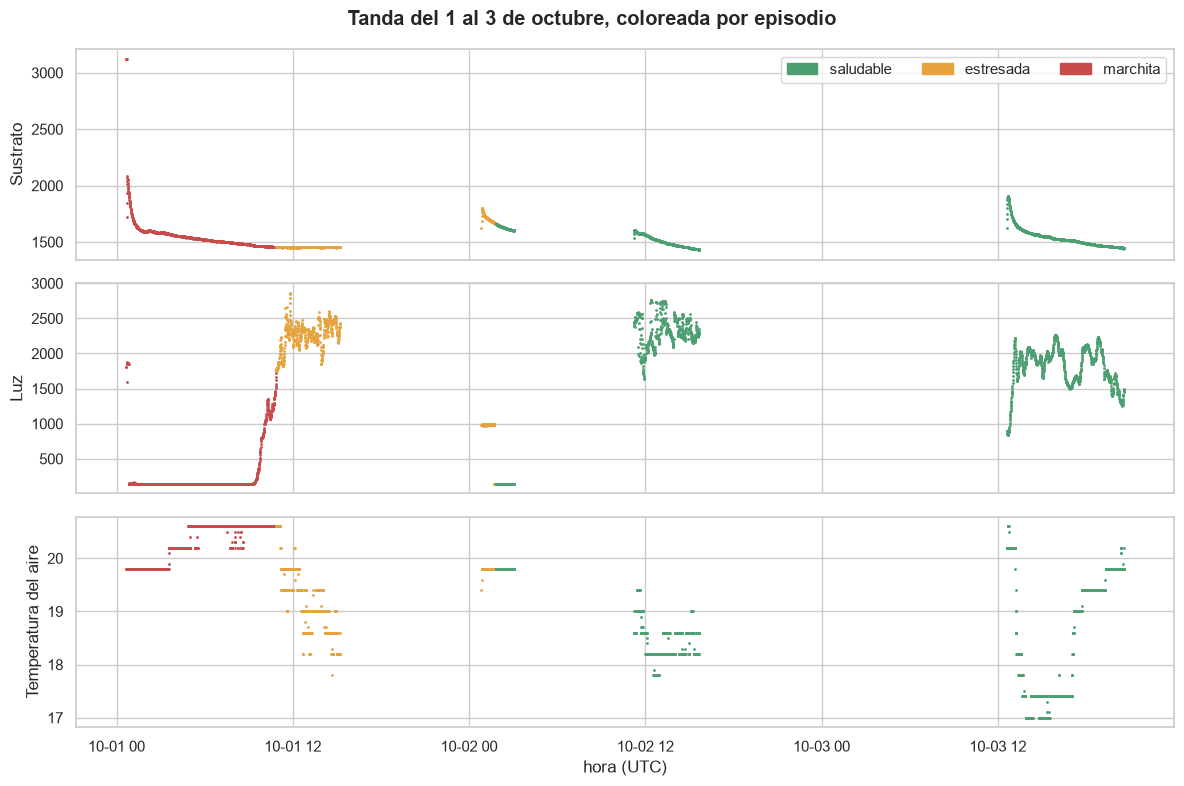

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
rn = datos[datos.ts >= "2026-10-01"]
for ax, col in zip(axes, ["suelo_mv", "luz_mv", "temperatura_c"]):
    for e, tramo in rn.groupby("episodio"):
        ax.plot(tramo.ts, tramo[col], ".", ms=2, color=COLORES[str(tramo.etiqueta.iloc[0])])
    ax.set_ylabel(VARIABLES[col].split(" (")[0])
axes[-1].set_xlabel("hora (UTC)")
axes[0].legend(handles=[Patch(color=COLORES[c], label=c) for c in CLASES], loc="upper right", ncol=3)
fig.suptitle("Tanda del 1 al 3 de octubre, coloreada por episodio", fontweight="bold")
fig.tight_layout()
fig.savefig(SALIDAS / "14_tanda_real_octubre.png", dpi=150, bbox_inches="tight")
plt.show()

**Lo que muestra la tanda.**

1. **La primera etiqueta es dudosa.** El episodio `marchita` del 1/10 transcurre de noche (luz ≈ 146 mV, la oscuridad del LDR) y con el sustrato en ~1.550 mV. En septiembre la `marchita` tenía el sustrato en ~2.700 mV y la `saludable` en ~1.800–2.200. En esta tanda el promedio del sustrato es casi idéntico en las tres clases (1.500 / 1.547 / 1.534 mV para `estresada` / `marchita` / `saludable`): **el sustrato no separa nada**. O la planta no estaba marchita, o la sonda no mide lo que se cree; sin la foto de la ESP32-CAM de esa hora no se puede decidir, por eso la nota del episodio 8 lo marca como etiqueta a revisar.
2. **El sustrato decae como una exponencial después de cada reinicio** (≈ 2.000 → 1.450 mV el 1/10; ≈ 1.800 → 1.600 el 2/10; ≈ 1.900 → 1.450 el 3/10). Una planta no se rehidrata tres veces en tres días sin riego registrado. Es más probable que sea un transitorio de la sonda resistiva o del arranque de la placa (hipótesis, no verificada). Si es así, parte de la variación del sustrato mide el dispositivo y no la planta.
3. **Luz y temperatura siguen al reloj, no a la planta.** La luz sube a media mañana y la temperatura del aire se mueve entre 17 y 20,6 °C según la hora; la clase cambia en las mismas horas porque la persona observó en esas horas.

## 3. ¿La etiqueta describe a la planta o al reloj?

,todo,sin etiqueta corregida
Luz (mV),0.35,0.34
Temperatura del aire (°C),0.02,0.24
Humedad del aire (%),0.23,0.09
Sustrato (mV; mayor = más seco),0.17,0.09


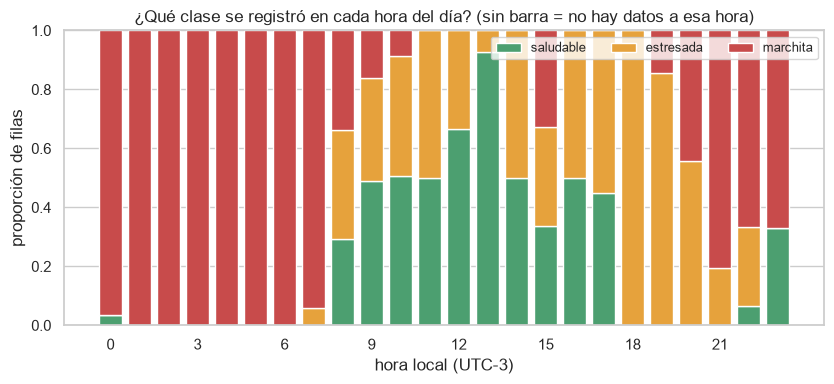

V de Cramér entre 'es de noche' y la clase: 0.7


In [6]:
def eps2(d, col):
    grupos = [d.loc[d.etiqueta == c, col].dropna() for c in CLASES]
    grupos = [g for g in grupos if len(g) > 1]
    H, _ = stats.kruskal(*grupos)
    return (H - len(grupos) + 1) / (len(d) - len(grupos))

conjuntos = {"todo": datos, "sin etiqueta corregida": datos[datos.origen_ep != "corregida"]}
display(pd.DataFrame({n: {VARIABLES[c]: eps2(d, c) for c in V} for n, d in conjuntos.items()}).round(3))

fig, ax = plt.subplots(figsize=(8.5, 4))
p = pd.crosstab(datos.hora_local, datos.etiqueta).reindex(index=range(24), columns=CLASES).fillna(0)
p = p.div(p.sum(axis=1).replace(0, np.nan), axis=0)
b = np.zeros(24)
for c in CLASES:
    v = p[c].fillna(0).values
    ax.bar(p.index, v, bottom=b, color=COLORES[c], label=c); b += v
ax.set(xlabel="hora local (UTC-3)", ylabel="proporción de filas", xticks=range(0, 24, 3),
       title="¿Qué clase se registró en cada hora del día? (sin barra = no hay datos a esa hora)")
ax.legend(loc="upper right", ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig(SALIDAS / "16_clase_por_hora.png", dpi=150, bbox_inches="tight")
plt.show()

t = pd.crosstab(datos.es_noche, datos.etiqueta)
print("V de Cramér entre 'es de noche' y la clase:",
      round(float(np.sqrt(stats.chi2_contingency(t)[0] / (t.values.sum() * (min(t.shape) - 1)))), 2))

**Confusión entre clase y hora del día.** Casi todas las filas de la noche (0 a 7 h) son `marchita` y casi todas las diurnas son `saludable` o `estresada`. La asociación entre "es de noche" y la clase es fuerte (V de Cramér = 0,70). La luz tiene el mayor efecto (ε² = 0,35), pero eso es el ciclo día/noche: la planta no se marchita por la noche.

Al agregar la tanda de octubre, el efecto aparente de la temperatura cayó de 0,45 (primera entrega) a 0,02, porque ahora las tres clases se observaron a temperaturas parecidas. Sin la etiqueta corregida sube a 0,24: con 7 u 8 episodios, el tamaño de efecto es muy inestable.

## 4. Validación: partición aleatoria frente a partición por episodio

Se entrenó un Random Forest (300 árboles) con cada subconjunto de variables y se midió la exactitud balanceada (el azar con 3 clases es 0,33) con dos esquemas: `StratifiedKFold` mezclando filas, y `GroupKFold` dejando cada episodio entero fuera del entrenamiento.

In [7]:
def evaluar(d, cols, por_episodio):
    X, y, g = d[cols].values, d.etiqueta.astype(str).values, d.episodio.values
    modelo = RandomForestClassifier(300, min_samples_leaf=5, random_state=0, n_jobs=-1)
    cv = GroupKFold(n_splits=5) if por_episodio else StratifiedKFold(5, shuffle=True, random_state=0)
    pred = cross_val_predict(modelo, X, y, cv=cv, groups=g if por_episodio else None)
    return balanced_accuracy_score(y, pred), pred

filas, preds = [], {}
for nombre, cols in [("las 4 variables", V), ("solo sustrato", ["suelo_mv"]),
                     ("sin sustrato (luz, temp., humedad)", ["luz_mv", "temperatura_c", "humedad_ambiente_pct"])]:
    for por_ep in (False, True):
        acc, pred = evaluar(datos, cols, por_ep)
        filas.append({"variables": nombre, "partición": "por episodio" if por_ep else "aleatoria",
                      "exactitud balanceada": acc})
        preds[(nombre, por_ep)] = pred
display(pd.DataFrame(filas).pivot_table(index="variables", columns="partición",
                                        values="exactitud balanceada").round(3))

partición,aleatoria,por episodio
variables,,
las 4 variables,1.00,0.05
"sin sustrato (luz, temp., humedad)",0.99,0.04
solo sustrato,0.79,0.15


**Resultado.**

| variables | partición aleatoria | por episodio |
|---|---|---|
| las 4 | 1,00 | 0,05 |
| solo sustrato | 0,79 | 0,15 |
| sin sustrato (luz, temp., humedad) | 0,99 | 0,04 |

Con filas mezcladas el modelo "acierta" el 100 %; con episodios completos fuera del entrenamiento, el 5 %, por debajo del azar. Con solo 10 episodios y cada clase concentrada en pocos, lo que el modelo aprende es *a qué episodio pertenece una fila* (por la hora, la luz, la temperatura de ese día), no la condición de la planta. Es el leakage descrito en el CLAUDE.md y acá se ve con números.

La matriz de confusión lo confirma: el modelo no acierta ninguna fila `saludable` (las manda a `estresada`) y casi ninguna `marchita`.

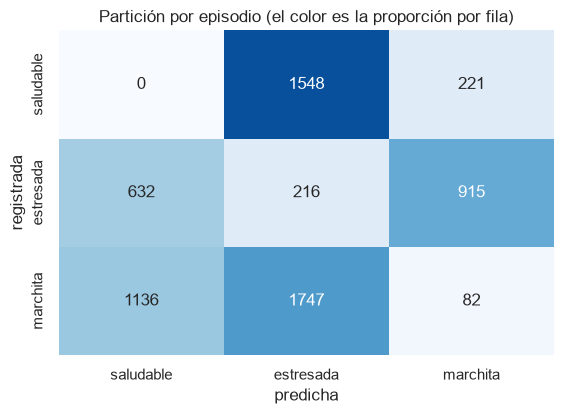

In [8]:
y = datos.etiqueta.astype(str).values
cm = confusion_matrix(y, preds[("las 4 variables", True)], labels=CLASES)
fig, ax = plt.subplots(figsize=(5.8, 4.3))
sns.heatmap(cm / cm.sum(axis=1, keepdims=True).clip(1), annot=cm, fmt="d", cmap="Blues", vmin=0, vmax=1,
            xticklabels=CLASES, yticklabels=CLASES, cbar=False, ax=ax)
ax.set(title="Partición por episodio (el color es la proporción por fila)", xlabel="predicha", ylabel="registrada")
fig.tight_layout()
fig.savefig(SALIDAS / "17_confusion_por_episodio.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Conclusiones

1. **Más datos manuales.** El dataset tiene ahora 10 episodios (7 anclados en una observación) frente a 7, repartidos en 8 días de calendario. Sigue siendo insuficiente para entrenar: cada clase vive en pocos episodios y casi siempre a la misma hora.
2. **La cadencia no es la del protocolo.** La placa sigue enviando cada 30 s, no cada 5 min. Hay que volver a flashear el firmware con `INTERVALO_ENVIO = 300000` y subir `FW_VERSION`, para poder separar en el análisis lo medido antes y después.
3. **La etiqueta del 1/10 no es consistente con el sustrato.** Una `marchita` con el sustrato igual que `saludable` pide revisión con las fotos de la ESP32-CAM antes de usarla; hasta entonces es la menos confiable de las manuales.
4. **El sustrato mezcla planta y dispositivo.** Los transitorios exponenciales tras cada reinicio no pueden ser humedad real. Hay que descartar los primeros minutos después de un `boot_id` nuevo, registrar cada riego aparte y seguir con la calibración semanal de la sonda.
5. **Una validación por filas miente.** 100 % con partición aleatoria frente a 5 % por episodio. Cualquier modelo que se reporte tiene que usar `GroupKFold` por episodio y declarar cuántos episodios hay.
6. **Cómo mejorar la recolección.** Apretar el botón cuando la planta *cambia* (antes y después de cada riego, cuando aparece una hoja caída) y no a horas fijas; cubrir varios días de clima distinto; y conseguir más episodios de `marchita` sin dañar la planta, con fotos de respaldo.